In [1]:
import numpy as np
import sdeint
import matplotlib.pyplot as plt
import os
import pickle
import csv

# Functions

In [2]:
#frequency sweep
def omega(t):
    return w1 + (w2-w1)*t/T
    

def delta(t):
    return 2*np.pi*δf*t


#Build matrices for the Îto equation
def a(t):
    return gamma*omega(t)
def b(t):
    return omega0**2-omega(t)**2 + lam/2.*omega0**2
def c(t):
    return -omega0**2+omega(t)**2 + lam/2.* omega0**2
#d=a

def A(t):
    return -1./(2.* omega(t)) *np.array([[a(t),b(t)],[c(t),a(t)]])
def sigma1(t):
    return sigma/(np.sqrt(2.)*m*omega(t))
def sigma2(t):
    return sigma/(np.sqrt(2.)*m*omega(t))
def B(t):
    return np.diag([sigma1(t), sigma2(t)])

#Build matrices for the Îto equation
def a_t(t):
    return gamma*omega
def b_t(t):
    return omega0_t(t)**2-omega**2 + lam/2.*omega0_t(t)**2
def c_t(t):
    return -omega0_t(t)**2+omega**2 + lam/2.* omega0_t(t)**2
#d=a

def A_t(t):
    return -1./(2.* omegaa) *np.array([[a_t(t),b_t(t)],[c_t(t),a_t(t)]])
def sigma1_t(t):
    return sigma/(np.sqrt(2.)*m*omegaa)
def sigma2_t(t):
    return sigma/(np.sqrt(2.)*m*omegaa)
def B_t(t):
    return np.diag([sigma1_t(t), sigma2_t])

In [3]:
#Ito equation: dx = f(x,t) dt + G(x,t) dW

def G(x, t):
    return B(t) 

def X2(x):
    return x[0]**2 + x[1]**2

def f2(x,t):
    return -1./(2.*omega(t))* np.array([[a(t) + X2(x)*omega(t) *eta/4., alpha*3./4.*X2(x) +b(t)],[-alpha*3./4.*X2(x)+c(t),a(t)  + X2(x)*omega(t) *eta/4.]]).dot(x) + F0/(2.*m*omega(t)) *np.array([np.sin(theta),-np.cos(theta)])+F1/(2.*m*omega(t)) *np.array([np.sin(theta+delta(t)),-np.cos(theta+delta(t))])

In [4]:
# mechanical parameters from fit of the linear response
# array structure:  2*pi f0 (Hz), Gamma(Hz), ph_off (deg), F0_fit (V), Cal (V/V), background real, background im

params = [6.969861595252762549e+06,6.802727485229268041e+02,-5.256241134670488258e+00,5.431471505824015185e+04,1.078743099468523264e+07,2.556991435269812915e-07,-5.845325698281949795e-17]


In [5]:
##### time trace at fixed frequency #######################
##### frequency sweep #######################
omega0 = 2*np.pi
cal = params[4]
f0 = params[0]/2/np.pi
Q = params[0]/params[1]
sigma = 0.0
m = 1
gamma = omega0/Q
Vp = 0
lam = Vp/4.7*2/Q
theta = -0.07348518484102952#-np.pi/4
#Fmod = 0.2 # relative force modulation depth
#fmod = 1e-3 # relative force modulation frequency
CF0 = 1.0787430994685232e7#2.65e10
alpha0 =  1.89e17#3.15e17
Vd = 0.140
V1 = 0.03
δf = 10/f0
F0 = CF0 * Vd/f0**3 * np.sqrt(alpha0)
F1 = CF0 * V1/f0**3 * np.sqrt(alpha0)

eta0 = 0*1.35e9#5.8e8
eta0 = 0*1.35e9#5.8e8
eta = eta0*f0/alpha0 #0.0000000004
alpha = -1
w1 = 1109139.464882943/f0*omega0 #wStart
w2 =1109139.464882943/f0*omega0 #wStop
T = 1000000

tspan = np.linspace(0.0, T, 40001) # array with time steps
x0 = np.array([0,  1e-9]) # initial condition

result = sdeint.itoint(f2, G, x0, tspan) # u,v-values
u = result[:,0]*np.sqrt(m*(f0)**2/alpha0)
v = result[:,1]*np.sqrt(m*(f0)**2/alpha0)


0.00035246271244050183


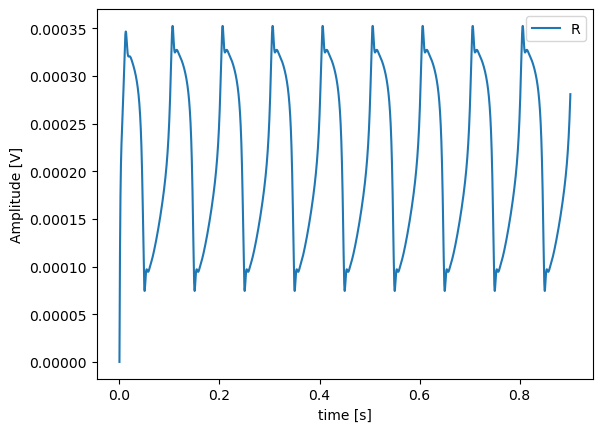

In [7]:
#plot amplitude time trace of x(t)
plt.plot(tspan/f0,np.sqrt(u**2 + v**2), label="R")
#plt.plot(tspan/f0, F1*np.cos(δf*2*np.pi*tspan+theta))
#plt.plot(freq, amplitude)
plt.xlabel(r"time [s]")
plt.ylabel(r"Amplitude [V]")
plt.legend()
#plt.savefig('Transient_w.png', format='png', dpi=300)
plt.show()